Number of coefficient arrays: 5
Threshold: 3.7635343098158973
Anomaly limit: 1.8977889690970147
Anomalies found: 48


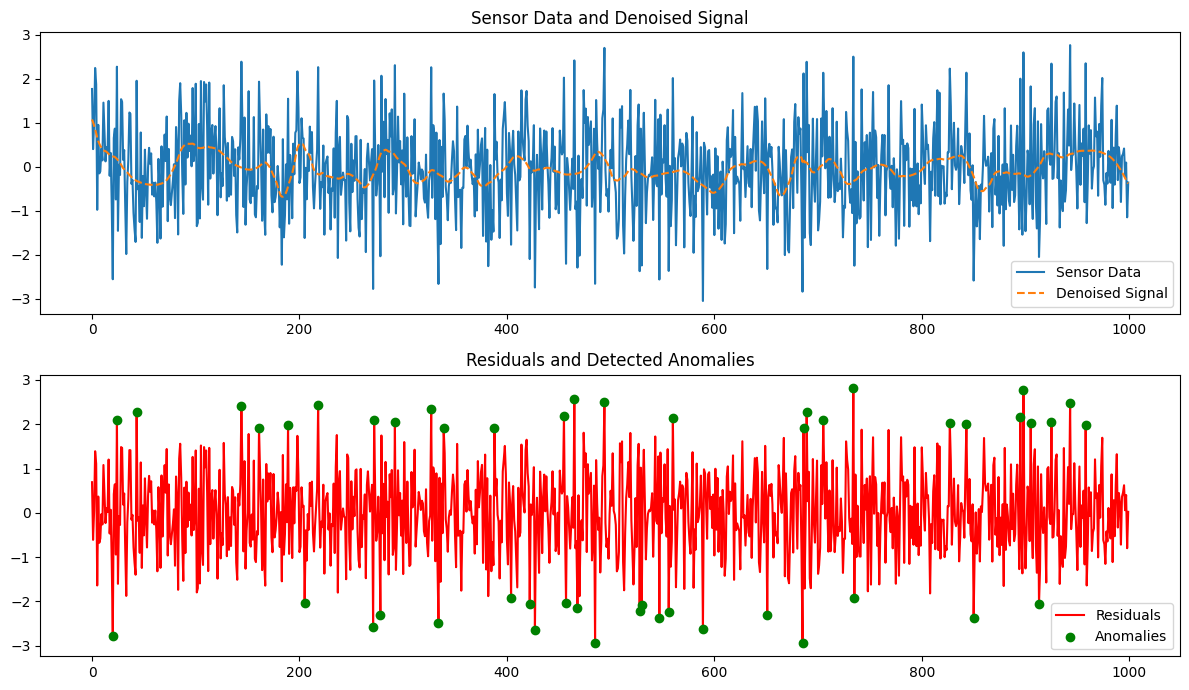

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# Sample sensor data (1000 readings)
np.random.seed(0)
sensor_data = np.random.normal(0, 1, 1000)

# Wavelet transform (DWT) using db4 wavelet, 4 levels
coeffs = pywt.wavedec(sensor_data, "db4", level=4)
print("Number of coefficient arrays:", len(coeffs))

# Find threshold for removing noise
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(sensor_data)))
print("Threshold:", threshold)

# Apply soft threshold on detail coefficients
# coeffs[0] is approximation so we keep it same
new_coeffs = [coeffs[0]]
for c in coeffs[1:]:
    new_coeffs.append(pywt.threshold(c, threshold, mode="soft"))

# Inverse wavelet transform to get denoised signal
denoised = pywt.waverec(new_coeffs, "db4")
denoised = denoised[:len(sensor_data)]

# Residuals = original - denoised
residuals = sensor_data - denoised

# if residual is more than 2 std, it is an anomaly
limit = 2 * np.std(residuals)
anomalies = np.where(np.abs(residuals) > limit)[0]
print("Anomaly limit:", limit)
print("Anomalies found:", len(anomalies))

# Plot results
plt.figure(figsize=(12, 7))

plt.subplot(2, 1, 1)
plt.plot(sensor_data, label="Sensor Data")
plt.plot(denoised, "--", label="Denoised Signal")
plt.title("Sensor Data and Denoised Signal")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(residuals, "r", label="Residuals")
plt.scatter(anomalies, residuals[anomalies], color="g", label="Anomalies", zorder=3)
plt.title("Residuals and Detected Anomalies")
plt.legend()

plt.tight_layout()
plt.show()